### Criação da série temporal anual

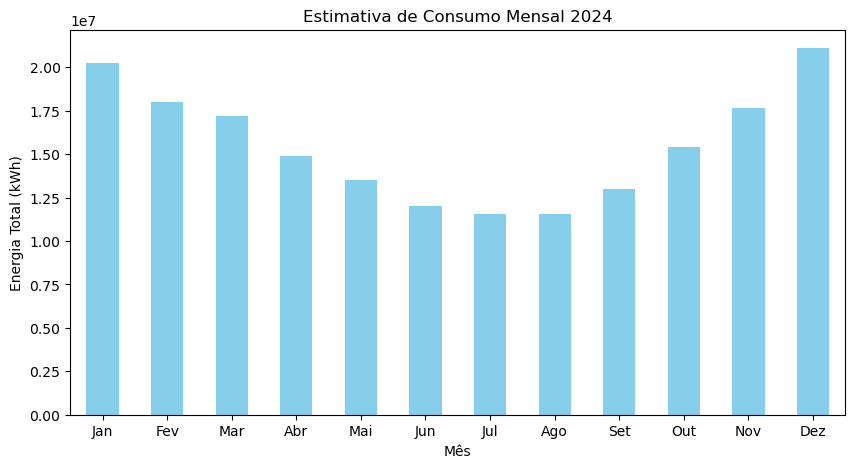

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar os dados originais
# Nota: O ficheiro original usa ';' como separador
df = pd.read_csv('consumoshorariocodigopostal3781a4420.csv', sep=';')

# Converter a coluna de Data/Hora para o formato datetime
df['Data/Hora'] = pd.to_datetime(df['Data/Hora'])

# 2. Agrupar por hora para obter o consumo total (soma de todos os códigos postais)
# Isso cria a base do que aconteceu em Fevereiro
feb_hourly = df.groupby('Data/Hora')['Energia ativa (kWh)'].sum().reset_index()
feb_hourly['hour'] = feb_hourly['Data/Hora'].dt.hour
feb_hourly['day_of_week'] = feb_hourly['Data/Hora'].dt.dayofweek

# 3. Criar um "Perfil Semanal Médio"
# Extraímos a média de consumo para cada hora de cada dia da semana (0=Segunda, 6=Domingo)
# Isto garante que as segundas-feiras de Julho tenham o "perfil" de uma segunda-feira.
avg_week_profile = feb_hourly.groupby(['day_of_week', 'hour'])['Energia ativa (kWh)'].mean().reset_index()

# 4. Criar o esqueleto para o ano de 2024 completo
# 2024 é ano bissexto, por isso terá 8784 horas
full_year_range = pd.date_range(start='2024-01-01 00:00:00', end='2024-12-31 23:00:00', freq='h', tz='UTC')
annual_df = pd.DataFrame({'Data/Hora': full_year_range})
annual_df['month'] = annual_df['Data/Hora'].dt.month
annual_df['hour'] = annual_df['Data/Hora'].dt.hour
annual_df['day_of_week'] = annual_df['Data/Hora'].dt.dayofweek

# 5. Definir os multiplicadores sazonais
# Baseado na premissa: Inverno > Fevereiro > Verão
# Janeiro é ligeiramente superior a Fevereiro, Verão desce até ~60% do consumo.
multipliers = {
    1: 1.05,  # Janeiro (Frio)
    2: 1.0,   # Fevereiro (Base)
    3: 0.90,  # Março
    4: 0.80,  # Abril
    5: 0.70,  # Maio
    6: 0.65,  # Junho
    7: 0.60,  # Julho (Calor/Menos consumo de aquecimento)
    8: 0.60,  # Agosto
    9: 0.70,  # Setembro
    10: 0.80, # Outubro
    11: 0.95, # Novembro
    12: 1.10  # Dezembro (Pico de Inverno)
}

annual_df['multiplier'] = annual_df['month'].map(multipliers)

# 6. Combinar o perfil semanal médio com o calendário anual
annual_df = annual_df.merge(avg_week_profile, on=['day_of_week', 'hour'], how='left')

# 7. Calcular o consumo final estimado
# Consumo = (Média daquela hora/dia em Fev) * (Fator do Mês)
annual_df['Energia_Estimada_kWh'] = annual_df['Energia ativa (kWh)'] * annual_df['multiplier']

# Limpeza final do DataFrame
final_annual_df = annual_df[['Data/Hora', 'Energia_Estimada_kWh']].copy()
final_annual_df.rename(columns={'Energia_Estimada_kWh': 'Energia ativa (kWh)'}, inplace=True)

# 8. Guardar o resultado
final_annual_df.to_csv('consumo_anual_estimado_2024.csv', index=False)

# --- Visualização Opcional ---
monthly_total = final_annual_df.groupby(final_annual_df['Data/Hora'].dt.month)['Energia ativa (kWh)'].sum()
plt.figure(figsize=(10, 5))
monthly_total.plot(kind='bar', color='skyblue')
plt.title('Estimativa de Consumo Mensal 2024')
plt.xlabel('Mês')
plt.ylabel('Energia Total (kWh)')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'], rotation=0)
plt.show()

In [2]:
import pandas as pd
import numpy as np

# 1. Carregar os dados do ficheiro CSV original
# O separador no teu ficheiro é ';'
df = pd.read_csv('consumoshorariocodigopostal3781a4420.csv', sep=';')

# Converter a coluna Data/Hora para o formato datetime do Pandas
df['Data/Hora'] = pd.to_datetime(df['Data/Hora'])

# 2. Agregação Inicial
# Como o ficheiro tem vários códigos postais, somamos o consumo por hora 
# para obter o perfil total da região em Fevereiro.
feb_hourly = df.groupby('Data/Hora')['Energia ativa (kWh)'].sum().reset_index()
feb_hourly['hora'] = feb_hourly['Data/Hora'].dt.hour
feb_hourly['dia_semana'] = feb_hourly['Data/Hora'].dt.dayofweek

# 3. Criar o Perfil Semanal Médio (Baseline)
# Agrupamos por dia da semana (0-6) e hora (0-23) para saber o consumo médio 
# de uma "segunda-feira às 10h", "domingo às 20h", etc.
perfil_semanal = feb_hourly.groupby(['dia_semana', 'hora'])['Energia ativa (kWh)'].mean().reset_index()

# 4. Gerar o Calendário Completo para 2024
# 2024 é ano bissexto (8784 horas)
ano_completo = pd.date_range(start='2024-01-01 00:00:00', end='2024-12-31 23:00:00', freq='h', tz='UTC')
df_anual = pd.DataFrame({'Data/Hora': ano_completo})
df_anual['mes'] = df_anual['Data/Hora'].dt.month
df_anual['hora'] = df_anual['Data/Hora'].dt.hour
df_anual['dia_semana'] = df_anual['Data/Hora'].dt.dayofweek

# 5. Definir a Sazonalidade (Inverno > Verão)
# Criamos um dicionário de multiplicadores onde Fevereiro (mês 2) é a base (1.0)
multiplicadores_sazonais = {
    1: 1.05,  # Janeiro (Frio intenso)
    2: 1.00,  # Fevereiro (Referência)
    3: 0.90,  # Março
    4: 0.80,  # Abril
    5: 0.70,  # Maio
    6: 0.65,  # Junho
    7: 0.60,  # Julho (Pico do Verão - menor consumo)
    8: 0.60,  # Agosto
    9: 0.70,  # Setembro
    10: 0.80, # Outubro
    11: 0.95, # Novembro
    12: 1.10  # Dezembro (Pico do Inverno)
}

df_anual['fator'] = df_anual['mes'].map(multiplicadores_sazonais)

# 6. Mapear o perfil de consumo e aplicar a sazonalidade
# Cruzamos o calendário do ano com o perfil semanal de Fevereiro
df_anual = df_anual.merge(perfil_semanal, on=['dia_semana', 'hora'], how='left')

# O consumo final é a média de Fevereiro ajustada pelo fator do mês
df_anual['Energia_Estimada_kWh'] = df_anual['Energia ativa (kWh)'] * df_anual['fator']

# 7. Limpeza e Exportação
resultado_final = df_anual[['Data/Hora', 'Energia_Estimada_kWh']].copy()
resultado_final.columns = ['Data/Hora', 'Energia ativa (kWh)']

# Guardar em CSV
resultado_final.to_csv('consumo_anual_estimado_2024.csv', index=False, sep=';')

print("Ficheiro anual gerado com sucesso!")

Ficheiro anual gerado com sucesso!
